# Buổi 9: Học sâu

Cài đặt thư viện tensorflow
```bash
pip install tensorflow
```

## 1. Khai báo thư viện 

In [32]:
%pip install tensorflow
import numpy as np
from tensorflow import keras    # thư viện keras cho deep learning
import matplotlib.pyplot as plt # thư viện vẽ đồ thị
import time

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 2. Chuẩn bị dữ liệu

In [33]:
# tải dataset mnist từ thư viện dataset chuẩn trong keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

## 3. Hiển thị dữ liệu

In [34]:
# Thông tin tập train
print(f'Train: n={len(x_train)}') 
print(f'+ x_train: {x_train.shape}, range = [{np.min(x_train)}, {np.max(x_train)}]') # shape + miền trị
print(f'+ y_train: {y_train.shape}, values= {np.unique(y_train)}') # shape + các giá trị output

# Thông tin tập test
print(f'Train: n={len(x_test)}') 
print(f'+ x_train: {x_test.shape}, range = [{np.min(x_test)}, {np.max(x_test)}]') # shape + miền trị
print(f'+ y_train: {y_test.shape}, values= {np.unique(y_test)}') # shape + các giá trị output

Train: n=60000
+ x_train: (60000, 28, 28), range = [0, 255]
+ y_train: (60000,), values= [0 1 2 3 4 5 6 7 8 9]
Train: n=10000
+ x_train: (10000, 28, 28), range = [0, 255]
+ y_train: (10000,), values= [0 1 2 3 4 5 6 7 8 9]


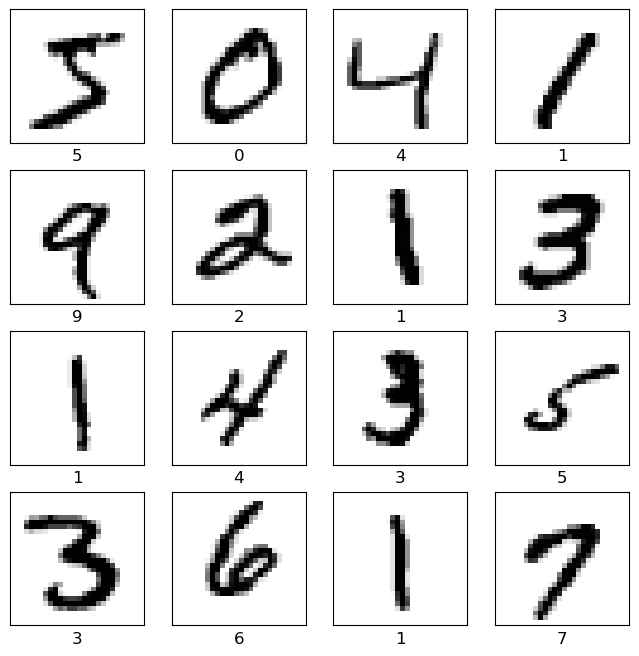

In [35]:
# Hiển thị dữ liệu train
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_train[i]}', fontsize = 12)
plt.show()

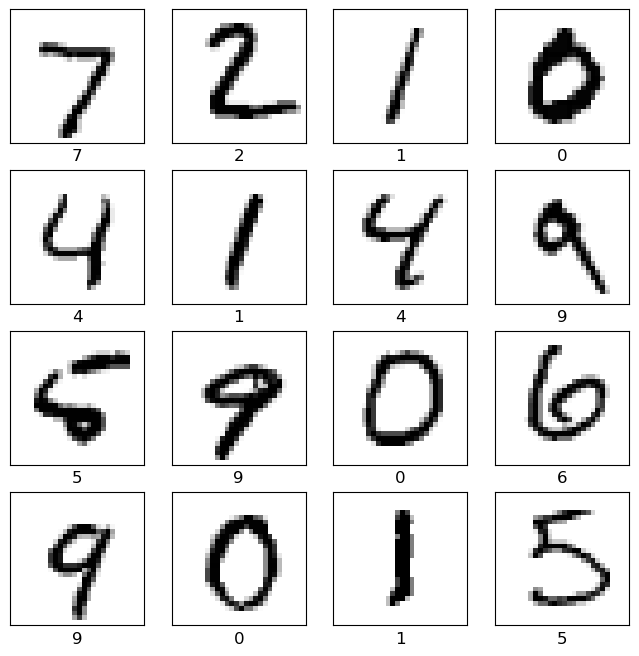

In [36]:
# Hiển thị dữ liệu test
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.xlabel(f'{y_test[i]}', fontsize = 12)
plt.show()

## 4. Tiền xử lý dữ liệu

In [37]:
# Biến đổi ảnh về miền trị [0,1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [38]:
# Mở rộng shape tại chiều cuối cùng (n_images,28,28) --> (n_images, 28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

In [39]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28, 1)
60000 train samples
10000 test samples


In [40]:
# Chuyển đổi y_train, y_test sang dạng one-hot
num_classes = 10 # phân lớp 10 ký tự số (từ 0 đến 9)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [41]:
# dạng one-hot
y_train[0:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [42]:
# dùng np.argmax để tìm vị trí có giá trị xác suất lớn nhất (đưa về label)
np.argmax(y_train[0:10], axis = 1)

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4])

## 5. Xây dựng Model

In [43]:
# xóa các lưu trữ 
keras.backend.clear_session() 

# xây dựng model
input_shape = (28, 28, 1)

# input
input_ = keras.Input(shape=input_shape)

# các blocks convolution để lấy features
# block 1 (conv2d + activation + maxpool)
x = keras.layers.Conv2D(32, kernel_size=(3, 3), activation="relu")(input_)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
# block 2 (conv2d + activation + maxpool)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)

# classification layers (gồm các dense layer, dropout)
x = keras.layers.Flatten()(x) # Đưa shape của x về dạng phẳng. Ví dụ: (28, 28, 1) --> (28x28x1, )
x = keras.layers.Dropout(0.5)(x) # Loại ngẫu nhiên 50% kết nối trong quá trình huấn luyện - tăng tính tổng quát hóa
output_ = keras.layers.Dense(num_classes, activation="softmax")(x) # kết xuất ra 10 classes dữ liệu dạng xác suất

model = keras.Model(inputs=input_, outputs=output_) # đưa vào model

model.summary() # hiển thị thông tin model

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Huấn luyện Model

In [44]:
# khai báo learning rate, loss function, và model metric
model.compile(loss='categorical_crossentropy', 
              optimizer=keras.optimizers.Adam(learning_rate=0.01), 
              metrics=["accuracy"])

batch_size = 128
epochs     = 15

starting_time = time.time()
model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.1)
print('> training time is %.4f minutes' % ((time.time() - starting_time)/60))

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9447 - loss: 0.1776 - val_accuracy: 0.9837 - val_loss: 0.0524
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9736 - loss: 0.0863 - val_accuracy: 0.9877 - val_loss: 0.0379
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9779 - loss: 0.0725 - val_accuracy: 0.9882 - val_loss: 0.0426
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9787 - loss: 0.0691 - val_accuracy: 0.9887 - val_loss: 0.0384
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9802 - loss: 0.0665 - val_accuracy: 0.9907 - val_loss: 0.0320
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9802 - loss: 0.0634 - val_accuracy: 0.9873 - val_loss: 0.0499
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9788 - loss: 0.0677 - val_accuracy: 0.9892 - val_loss: 0.0384
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9800 - loss: 0.0641 - val_accu

In [45]:
# list all data in history
print(model.history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


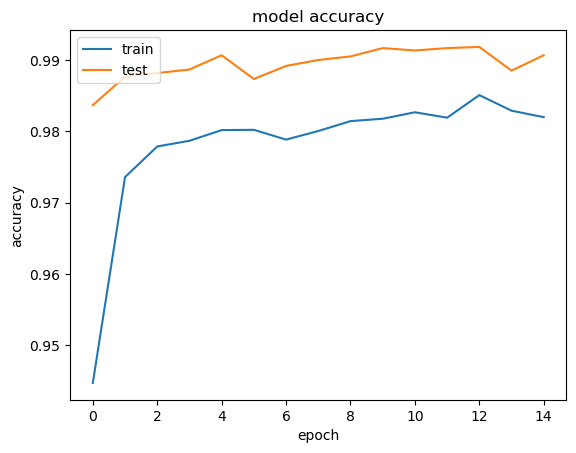

In [46]:
# summarize history for accuracy
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

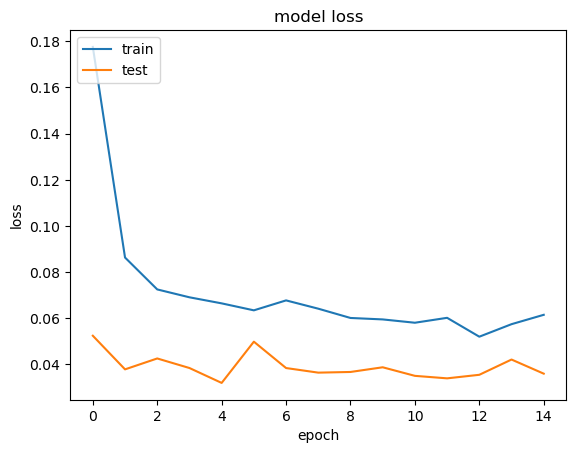

In [47]:
# summarize history for loss
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## 7. Lượng giá Model

In [48]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.035955190658569336
Test accuracy: 0.9894999861717224


In [49]:
y_pred = model.predict(x_test)
y_pred_label = np.argmax(y_pred, axis = 1)
y_gt_label = np.argmax(y_test, axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [50]:
# Các vị trí bị sai
false_pos = np.where(y_pred_label != y_gt_label)[0]
print(f'False Cases: {len(false_pos)} / {len(y_gt_label)}\n{false_pos}')

False Cases: 105 / 10000
[ 151  320  321  340  447  582  646  882  924  938 1014 1039 1112 1147
 1226 1232 1242 1247 1260 1281 1299 1393 1527 1681 1709 1737 1790 1901
 2035 2109 2129 2130 2135 2182 2185 2237 2266 2293 2414 2462 2597 2654
 2686 2720 2896 2921 2927 2970 2995 3012 3073 3384 3451 3475 3520 3534
 3558 3730 3780 3808 3850 3853 3893 3941 3968 3976 4078 4176 4205 4284
 4289 4369 4500 4571 4699 4740 4761 4783 4860 5068 5676 5735 5937 5955
 5997 6091 6172 6560 6571 6576 6597 6625 6796 7971 8094 8527 9009 9620
 9642 9664 9692 9729 9770 9792 9839]


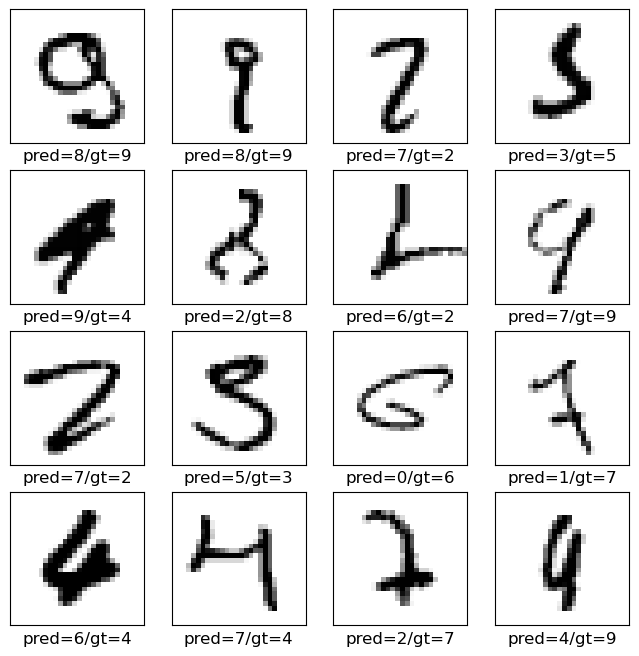

In [51]:
# Hiển thị dữ liệu test
plt.figure(figsize=(8, 8))
for i in range(16):
    pos = false_pos[i]
    plt.subplot(4,4,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[pos], cmap=plt.cm.binary)
    plt.xlabel(f'pred={y_pred_label[pos]}/gt={y_gt_label[pos]}', fontsize = 12)
plt.show()

# Kết thúc